In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer

# ------------------------------------------------------
# 1. Load and Inspect the Dataset
# ------------------------------------------------------
# Replace 'your_dataset.csv' with your dataset file path.
data = pd.read_csv('patients_data.csv')

# Print basic dataset information
print("Dataset Shape:", data.shape)
print("\nDataset Info:")
print(data.info())
print("\nDataset Sample:")
print(data.head())

# ------------------------------------------------------
# 2. Data Preprocessing
# ------------------------------------------------------
# Drop non-predictive Patient_ID
data = data.drop(columns=['Patient_ID'])

# Process the Symptoms column:
# Split comma-separated symptoms into lists.
data['Symptoms_List'] = data['Symptoms'].apply(lambda x: [sym.strip() for sym in x.split(',')])

# Use MultiLabelBinarizer to encode Symptoms
mlb = MultiLabelBinarizer()
symptoms_encoded = pd.DataFrame(
    mlb.fit_transform(data['Symptoms_List']),
    columns=mlb.classes_,
    index=data.index
)

# One-hot encode the Medical_History column
medical_history_encoded = pd.get_dummies(data['Medical_History'], prefix='MedHist')

# Combine features: Age, encoded Symptoms, and encoded Medical_History
X = pd.concat([data[['Age']], symptoms_encoded, medical_history_encoded], axis=1)

# Encode target: Diagnosis (we'll use this as our prediction target)
y, diagnosis_labels = pd.factorize(data['Diagnosis'])

# ------------------------------------------------------
# 3. Train-Test Split & Model Building
# ------------------------------------------------------
# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nTest Set Accuracy: {:.2f}".format(accuracy))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=diagnosis_labels))

# ------------------------------------------------------
# 4. Knowledge-Based Mapping for Next Best Action
# ------------------------------------------------------
# Create a simple mapping from Diagnosis to recommended Risk_Level and Recommended_Action.
# Update this dictionary as per clinical guidelines or external medical ontologies.
action_mapping = {
    'Liver Disease': {'Risk_Level': 'High', 'Recommended_Action': 'Emergency Response'},
    'Cancer':        {'Risk_Level': 'High', 'Recommended_Action': 'Hospitalization'},
    'Diabetes':      {'Risk_Level': 'Medium', 'Recommended_Action': 'Medication'},
    # Add more mappings as needed...
}

# ------------------------------------------------------
# 5. Predict for a New Patient Example & Recommend Action
# ------------------------------------------------------
# Example new patient data (update values as needed)
new_patient = pd.DataFrame({
    'Age': [50],
    'Symptoms': ['Fever, Headache, Cough'],
    'Medical_History': ['Hypertension']
})

# Preprocess new patient data:
# Process Symptoms
new_patient['Symptoms_List'] = new_patient['Symptoms'].apply(lambda x: [sym.strip() for sym in x.split(',')])
new_symptoms_encoded = pd.DataFrame(
    mlb.transform(new_patient['Symptoms_List']),
    columns=mlb.classes_
)

# One-hot encode Medical_History for new data
new_med_history_encoded = pd.get_dummies(new_patient['Medical_History'], prefix='MedHist')

# Combine all features
X_new = pd.concat([new_patient[['Age']].reset_index(drop=True),
                   new_symptoms_encoded.reset_index(drop=True),
                   new_med_history_encoded.reset_index(drop=True)], axis=1)

# Ensure the new data has the same columns as the training data:
missing_cols = set(X.columns) - set(X_new.columns)
for col in missing_cols:
    X_new[col] = 0
X_new = X_new[X.columns]  # Reorder columns

# Predict diagnosis for the new patient
new_pred = model.predict(X_new)
predicted_diagnosis = diagnosis_labels[new_pred[0]]
print("\nPredicted Diagnosis for New Patient:", predicted_diagnosis)

# Provide recommendation based on the knowledge-based mapping
if predicted_diagnosis in action_mapping:
    recommended_info = action_mapping[predicted_diagnosis]
    print("Recommended Risk Level:", recommended_info['Risk_Level'])
    print("Recommended Action:", recommended_info['Recommended_Action'])
else:
    print("No mapping available for the predicted diagnosis.")


Dataset Shape: (300000, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Patient_ID          300000 non-null  int64 
 1   Age                 300000 non-null  int64 
 2   Symptoms            300000 non-null  object
 3   Medical_History     300000 non-null  object
 4   Diagnosis           299999 non-null  object
 5   Risk_Level          300000 non-null  object
 6   Recommended_Action  299999 non-null  object
dtypes: int64(2), object(5)
memory usage: 16.0+ MB
None

Dataset Sample:
   Patient_ID  Age                                       Symptoms  \
0           1   66        Fatigue, Dizziness, Cough, Palpitations   
1           2   45                   Fatigue, Skin Rash, Headache   
2           3   27  WeiCancer,Highght Loss, Skin Rash, Joint Pain   
3           4   77                                       H

In [2]:
!pip install wordcloud

Dataset Shape: (300000, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Patient_ID          300000 non-null  int64 
 1   Age                 300000 non-null  int64 
 2   Symptoms            300000 non-null  object
 3   Medical_History     300000 non-null  object
 4   Diagnosis           299999 non-null  object
 5   Risk_Level          300000 non-null  object
 6   Recommended_Action  299999 non-null  object
dtypes: int64(2), object(5)
memory usage: 16.0+ MB
None

Dataset Sample:
   Patient_ID  Age                                       Symptoms  \
0           1   66        Fatigue, Dizziness, Cough, Palpitations   
1           2   45                   Fatigue, Skin Rash, Headache   
2           3   27  WeiCancer,Highght Loss, Skin Rash, Joint Pain   
3           4   77                                       H

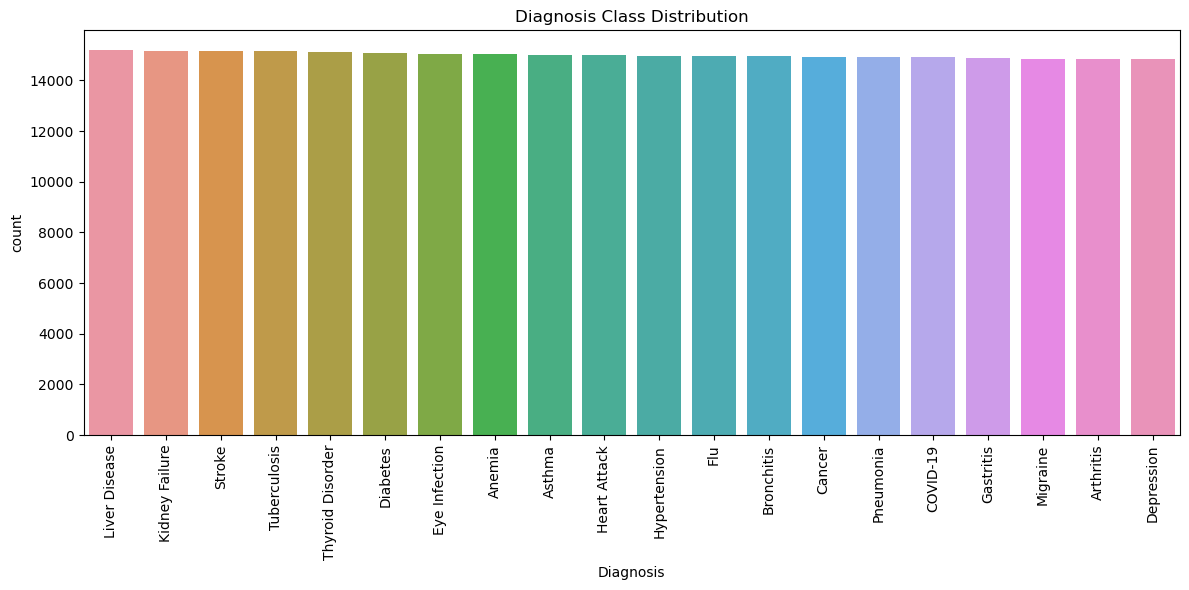

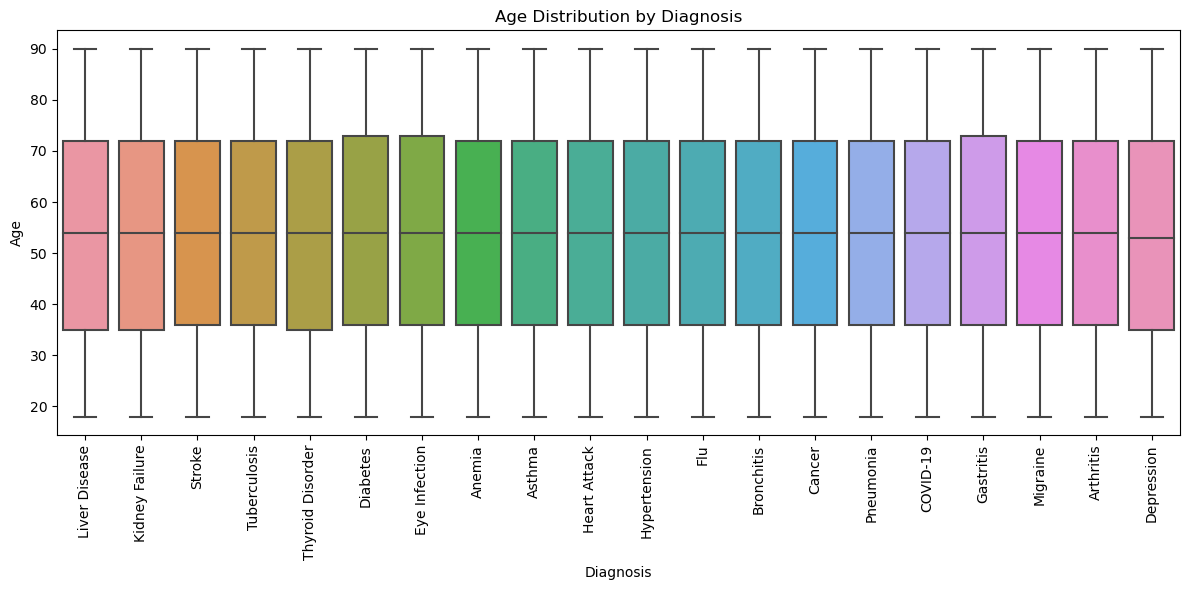

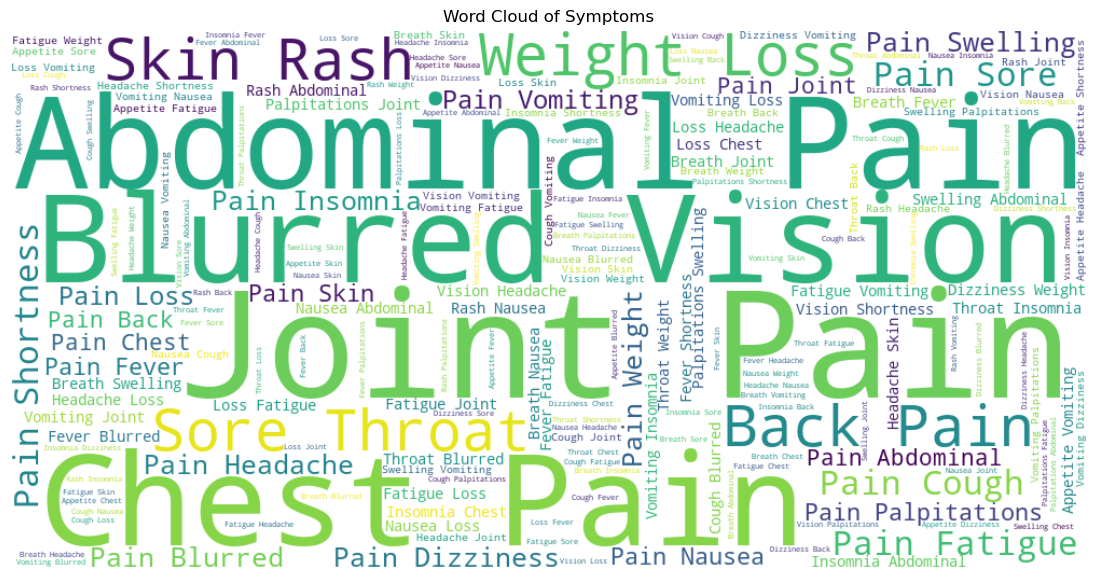


Shape of Combined Feature Matrix X: (300000, 41)

Test Set Accuracy with TF-IDF Features: 0.05

Classification Report:
                  precision    recall  f1-score   support

   Liver Disease       0.05      0.05      0.05      3036
          Cancer       0.05      0.05      0.05      2937
        Diabetes       0.05      0.05      0.05      3078
  Kidney Failure       0.05      0.05      0.05      3100
    Tuberculosis       0.05      0.05      0.05      3014
          Anemia       0.05      0.05      0.05      3087
      Bronchitis       0.05      0.05      0.05      3042
    Hypertension       0.05      0.05      0.05      3005
        Migraine       0.05      0.05      0.05      2977
        COVID-19       0.05      0.05      0.05      2997
    Heart Attack       0.05      0.05      0.05      3037
Thyroid Disorder       0.06      0.06      0.06      3072
             Flu       0.05      0.05      0.05      3003
          Stroke       0.05      0.05      0.05      3065
   Eye In

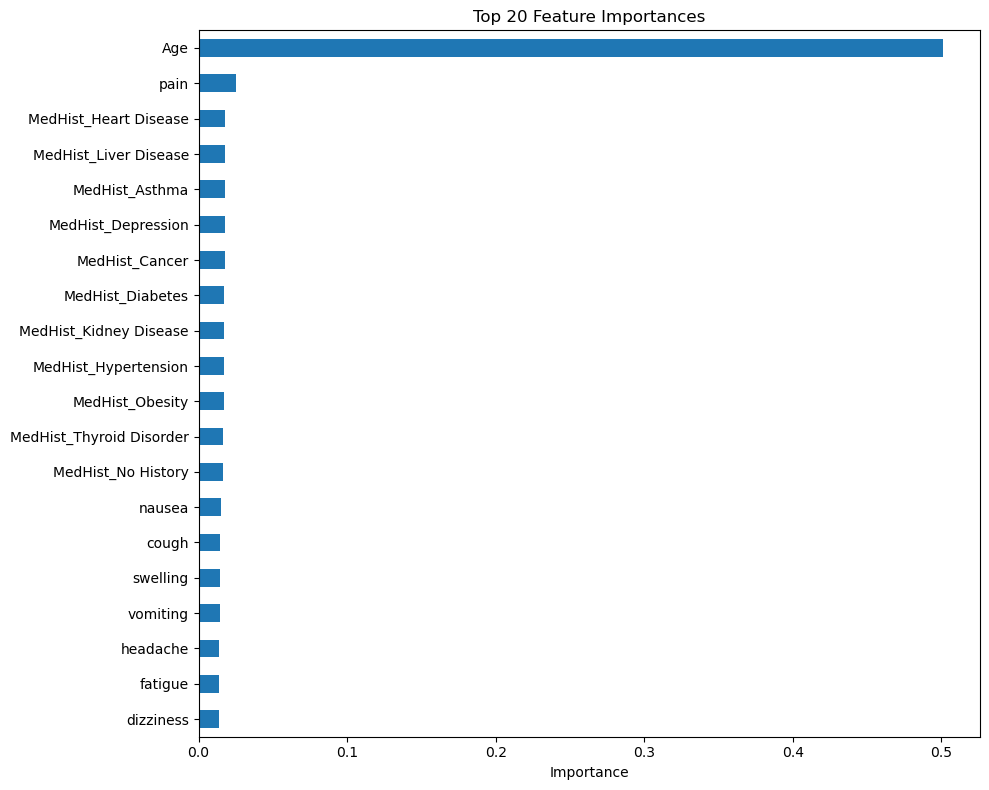

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# -------------------------
# 1. Data Loading & Exploration
# -------------------------
# Load your dataset (update the file path as necessary)
data = pd.read_csv('patients_data.csv')

# Print basic dataset information
print("Dataset Shape:", data.shape)
print("\nDataset Info:")
print(data.info())
print("\nDataset Sample:")
print(data.head())

# ----- Class Distribution for Diagnosis -----
plt.figure(figsize=(12,6))
sns.countplot(data=data, x='Diagnosis', order=data['Diagnosis'].value_counts().index)
plt.title('Diagnosis Class Distribution')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ----- Age Distribution by Diagnosis -----
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='Diagnosis', y='Age', order=data['Diagnosis'].value_counts().index)
plt.title('Age Distribution by Diagnosis')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ----- Word Cloud for Symptoms -----
# Combine all symptoms into one large string
all_symptoms = ','.join(data['Symptoms'])
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_symptoms)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Symptoms')
plt.show()

# -------------------------
# 2. Advanced Feature Engineering
# -------------------------
# Drop non-predictive columns
data_clean = data.drop(columns=['Patient_ID'])

# ----- Process Symptoms with TF-IDF -----
# Here, we treat the Symptoms field as text. 
# TF-IDF will capture more nuanced information than simply splitting by commas.
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', max_features=1000)  # You can adjust max_features as needed
symptoms_tfidf = tfidf_vectorizer.fit_transform(data_clean['Symptoms'])
symptoms_tfidf_df = pd.DataFrame(symptoms_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# ----- One-hot Encode Medical_History -----
medical_history_encoded = pd.get_dummies(data_clean['Medical_History'], prefix='MedHist')

# ----- Combine Features -----
# We'll use Age, TF-IDF of Symptoms, and Medical_History
X = pd.concat([data_clean[['Age']].reset_index(drop=True),
               symptoms_tfidf_df.reset_index(drop=True),
               medical_history_encoded.reset_index(drop=True)], axis=1)

# ----- Encode the Target Variable (Diagnosis) -----
y, diagnosis_labels = pd.factorize(data_clean['Diagnosis'])

print("\nShape of Combined Feature Matrix X:", X.shape)

# -------------------------
# 3. Model Building & Evaluation
# -------------------------
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nTest Set Accuracy with TF-IDF Features: {:.2f}".format(accuracy))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=diagnosis_labels))

# -------------------------
# 4. Feature Importance (Optional)
# -------------------------
importances = model.feature_importances_
features = X.columns
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,8))
feat_importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()


Dataset shape (rows, columns): (300000, 7)

Columns in the dataset:
['Patient_ID', 'Age', 'Symptoms', 'Medical_History', 'Diagnosis', 'Risk_Level', 'Recommended_Action']

First 5 rows:
   Patient_ID  Age                                       Symptoms  \
0           1   66        Fatigue, Dizziness, Cough, Palpitations   
1           2   45                   Fatigue, Skin Rash, Headache   
2           3   27  WeiCancer,Highght Loss, Skin Rash, Joint Pain   
3           4   77                                       Headache   
4           5   26         Fever, Vomiting, Sore Throat, Headache   

  Medical_History      Diagnosis       Risk_Level  Recommended_Action  
0      Depression  Liver Disease             High  Emergency Response  
1   Heart Disease            NaN  Hospitalization                 NaN  
2   Liver Disease         Cancer             High     Hospitalization  
3      Depression  Liver Disease             High  Emergency Response  
4        Diabetes       Diabetes        

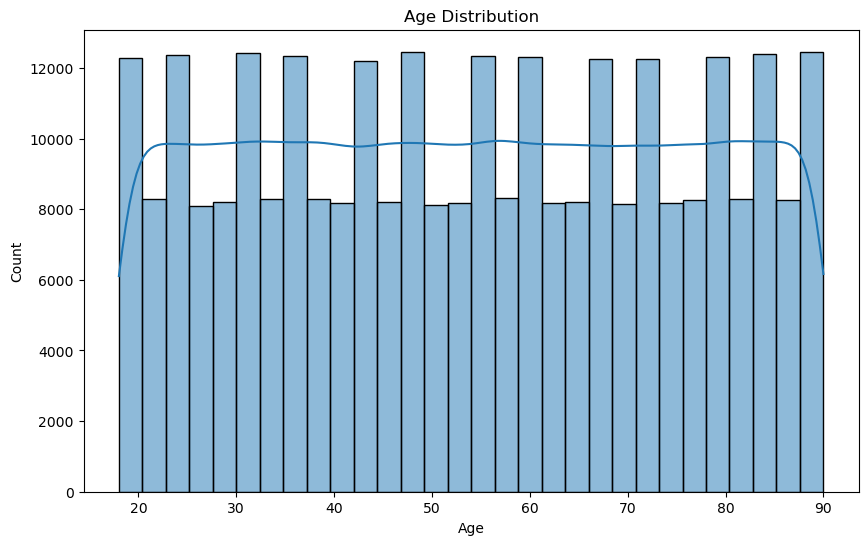

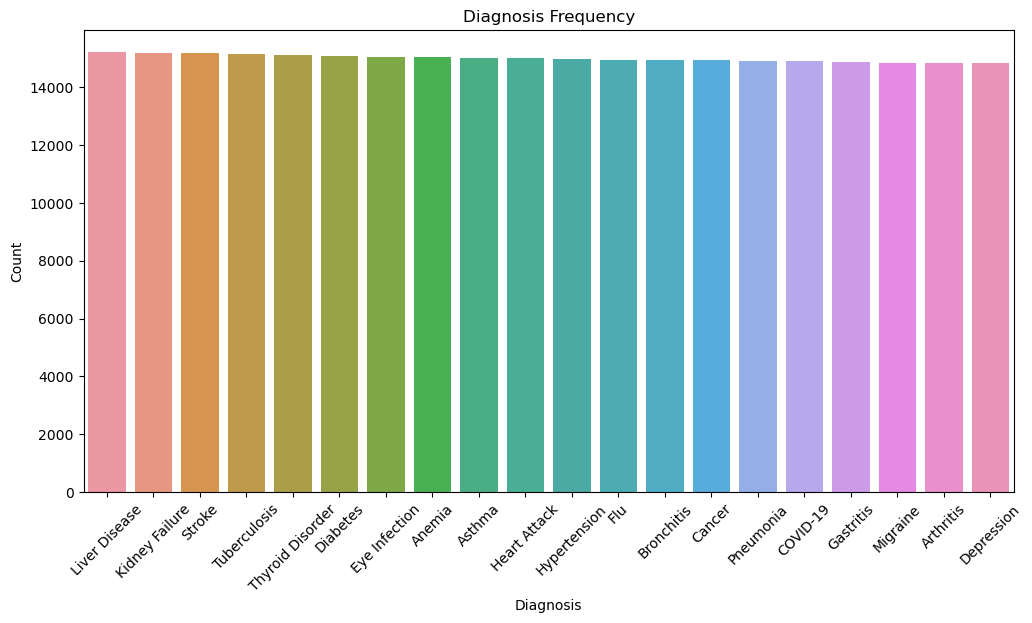

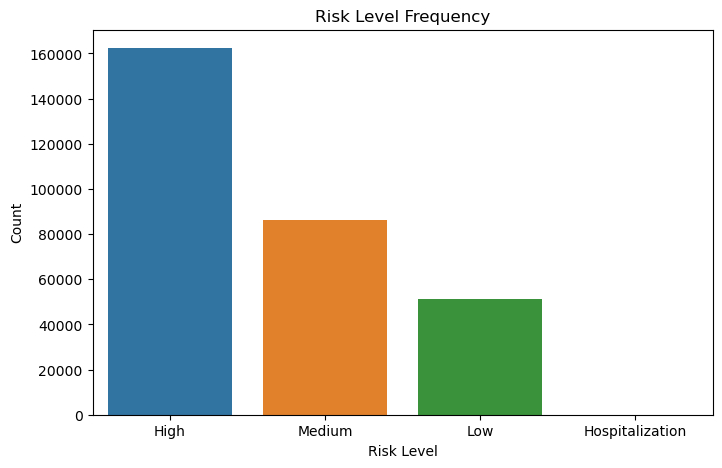


Sample cleaned Symptoms:
                                        Symptoms  \
0        Fatigue, Dizziness, Cough, Palpitations   
1                   Fatigue, Skin Rash, Headache   
2  WeiCancer,Highght Loss, Skin Rash, Joint Pain   
3                                       Headache   
4         Fever, Vomiting, Sore Throat, Headache   

                               Symptoms_clean  
0        fatigue dizziness cough palpitations  
1                  fatigue skin rash headache  
2  weicancerhighght loss skin rash joint pain  
3                                    headache  
4         fever vomiting sore throat headache  

Sample cleaned Medical History:
  Medical_History Medical_History_clean
0      Depression            depression
1   Heart Disease         heart disease
2   Liver Disease         liver disease
3      Depression            depression
4        Diabetes              diabetes


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the dataset (adjust the file path as needed)
df = pd.read_csv('patients_data.csv')

# --- Step 1: Data Overview ---
print("Dataset shape (rows, columns):", df.shape)
print("\nColumns in the dataset:")
print(df.columns.tolist())

# Display the first few rows to inspect the data
print("\nFirst 5 rows:")
print(df.head())

# --- Step 2: Data Quality Checks ---
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

# --- Step 3: Descriptive Statistics ---
# Basic statistics for numerical fields
print("\nSummary statistics for numerical fields:")
print(df.describe())

# --- Step 4: Basic Visualizations ---
# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Distribution of Diagnoses
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Diagnosis', order=df['Diagnosis'].value_counts().index)
plt.title("Diagnosis Frequency")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Distribution of Risk_Level
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Level', order=df['Risk_Level'].value_counts().index)
plt.title("Risk Level Frequency")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# --- Step 5: Text Cleaning for NLP (Symptoms & Medical_History) ---
def clean_text(text):
    """
    Basic text cleaning function:
      - Converts text to lowercase
      - Removes non-alphanumeric characters
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

# Create cleaned versions of the Symptoms and Medical_History columns
df['Symptoms_clean'] = df['Symptoms'].apply(clean_text)
df['Medical_History_clean'] = df['Medical_History'].apply(clean_text)

print("\nSample cleaned Symptoms:")
print(df[['Symptoms', 'Symptoms_clean']].head())

print("\nSample cleaned Medical History:")
print(df[['Medical_History', 'Medical_History_clean']].head())

# --- Next Steps ---
# At this point, your dataset has been loaded and checked.
# From here, you can proceed with:
# 1. Advanced feature engineering (e.g., using TF-IDF or transformer-based embeddings for text fields)
# 2. Building a patient-centric semantic network by mapping relationships between Symptoms, Diagnoses, etc.
# 3. Training a model (for example, a hybrid model using Graph Neural Networks and NLP components)
# 4. Developing a recommendation system for the next best action using rule-based or reinforcement learning methods


Dataset Head:
   Patient_ID  Age                                       Symptoms  \
0           1   66        Fatigue, Dizziness, Cough, Palpitations   
1           2   45                   Fatigue, Skin Rash, Headache   
2           3   27  WeiCancer,Highght Loss, Skin Rash, Joint Pain   
3           4   77                                       Headache   
4           5   26         Fever, Vomiting, Sore Throat, Headache   

  Medical_History      Diagnosis       Risk_Level  Recommended_Action  
0      Depression  Liver Disease             High  Emergency Response  
1   Heart Disease            NaN  Hospitalization                 NaN  
2   Liver Disease         Cancer             High     Hospitalization  
3      Depression  Liver Disease             High  Emergency Response  
4        Diabetes       Diabetes           Medium          Medication  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column   

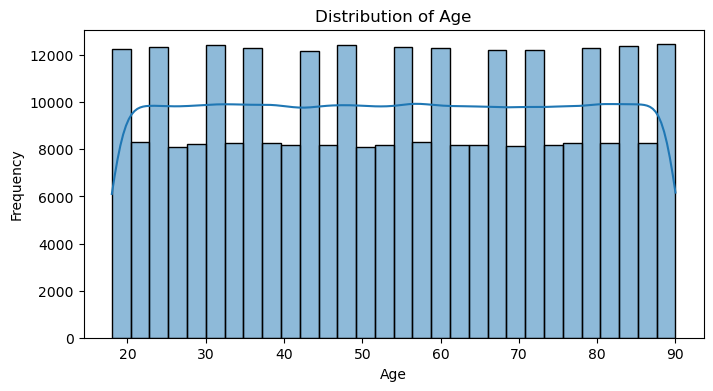


Unique Diagnoses:
['Liver Disease' 'Cancer' 'Diabetes' 'Kidney Failure' 'Tuberculosis'
 'Anemia' 'Bronchitis' 'Hypertension' 'Migraine' 'COVID-19' 'Heart Attack'
 'Thyroid Disorder' 'Flu' 'Stroke' 'Eye Infection' 'Asthma' 'Arthritis'
 'Gastritis' 'Pneumonia' 'Depression']

Training the model...

Evaluating the model on test data...
                  precision    recall  f1-score   support

          Anemia       0.05      0.05      0.05      3007
       Arthritis       0.05      0.05      0.05      2967
          Asthma       0.05      0.05      0.05      3002
      Bronchitis       0.05      0.05      0.05      2990
        COVID-19       0.05      0.05      0.05      2982
          Cancer       0.05      0.05      0.05      2985
      Depression       0.05      0.05      0.05      2965
        Diabetes       0.05      0.05      0.05      3015
   Eye Infection       0.06      0.06      0.06      3011
             Flu       0.06      0.05      0.05      2990
       Gastritis       0.0

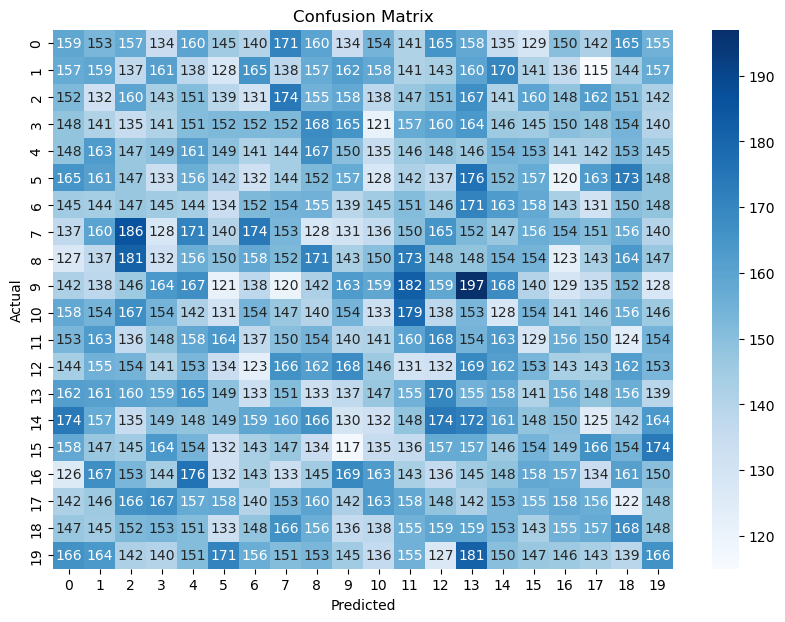

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning pipeline and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Data Ingestion & Basic Exploration
# Adjust the file path as necessary.
df = pd.read_csv('patients_data.csv')

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Display the first few rows and summary information
print("Dataset Head:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Value Counts:")
print(df.isnull().sum())

# 2. Data Cleaning & Preprocessing
# Since the dataset info shows that 'Diagnosis' (and possibly others) might be missing,
# drop rows where 'Diagnosis' is missing.
df = df.dropna(subset=['Diagnosis'])
print("\nDataset shape after dropping rows with missing 'Diagnosis':", df.shape)

# Create a new combined text column for NLP processing.
df['combined_text'] = df['Symptoms'].fillna('') + " " + df['Medical_History'].fillna('')

# Optional: Visualize the distribution of Age or any other numeric field.
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Check unique values in the Diagnosis field
print("\nUnique Diagnoses:")
print(df['Diagnosis'].unique())

# 3. Build a Machine Learning Pipeline
# Define features and target
X = df[['Age', 'combined_text']]
y = df['Diagnosis']

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define a ColumnTransformer to handle numeric and text data separately.
preprocessor = ColumnTransformer(
    transformers=[
        # Process numeric features: 'Age'
        ('num', StandardScaler(), ['Age']),
        # Process text features: 'combined_text'
        ('text', TfidfVectorizer(max_features=5000), 'combined_text')
    ]
)

# Build a pipeline that first preprocesses the data then fits a RandomForest classifier.
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# 4. Model Training
print("\nTraining the model...")
pipeline.fit(X_train, y_train)

# 5. Model Evaluation
print("\nEvaluating the model on test data...")
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

# Display a confusion matrix for further insights.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [6]:
!pip install tensorflow

  Using cached tensorflow-2.18.0-cp311-cp311-win_amd64.whl (7.5 kB)
  Using cached tensorflow_intel-2.18.0-cp311-cp311-win_amd64.whl (390.2 MB)
  Using cached absl_py-2.1.0-py3-none-any.whl (133 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached gast-0.6.0-py3-none-any.whl (21 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached grpcio-1.70.0-cp311-cp311-win_amd64.whl (4.3 MB)
  Using cached tensorboard-2.18.0-py3-none-any.whl (5.5 MB)
  Using cached keras-3.8.0-py3-none-any.whl (1.3 MB)
  Using cached numpy-2.0.2-cp311-cp311-win_amd64.whl (15.9 MB)
  Using cached h5py-3.13.0-cp311-cp311-win_amd64.whl (3.0 MB)
  Using cached ml_dtypes-0.4.1-cp311-cp311-win_amd64.whl (126 kB)
  Using cached rich-13.9.4-py3-none-any.whl (242 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\numpy-1.24.3.dist-info\\direct_url.json'
Consider using the `--user` option or check the permissions.



In [7]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\numpy-1.24.3.dist-info\\direct_url.json'
Consider using the `--user` option or check the permissions.



  Using cached tensorflow-2.18.0-cp311-cp311-win_amd64.whl (7.5 kB)
  Using cached tensorflow_intel-2.18.0-cp311-cp311-win_amd64.whl (390.2 MB)
  Using cached absl_py-2.1.0-py3-none-any.whl (133 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached gast-0.6.0-py3-none-any.whl (21 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached grpcio-1.70.0-cp311-cp311-win_amd64.whl (4.3 MB)
  Using cached tensorboard-2.18.0-py3-none-any.whl (5.5 MB)
  Using cached keras-3.8.0-py3-none-any.whl (1.3 MB)
  Using cached numpy-2.0.2-cp311-cp311-win_amd64.whl (15.9 MB)
  Using cached h5py-3.13.0-cp311-cp311-win_amd64.whl (3.0 MB)
  Using cached ml_dtypes-0.4.1-cp311-cp311-win_amd64.whl (126 kB)
  Using cached rich-13.9.4-py3-none-any.whl (242 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:


In [8]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# -------------------------------
# Load and Clean the Data
# -------------------------------
df = pd.read_csv('patients_data.csv')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['Symptoms_clean'] = df['Symptoms'].apply(clean_text)
df['Medical_History_clean'] = df['Medical_History'].apply(clean_text)

# -------------------------------
# Advanced Feature Engineering using TF-IDF
# -------------------------------

# Create TF-IDF vectorizers for Symptoms and Medical_History
# Optionally, increase max_features if you want more vocabulary size.
tfidf_symptoms = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
tfidf_medhist = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

# Fit and transform the text data
symptoms_tfidf = tfidf_symptoms.fit_transform(df['Symptoms_clean'])
medhist_tfidf = tfidf_medhist.fit_transform(df['Medical_History_clean'])

# Check shapes of the TF-IDF matrices
print("Symptoms TF-IDF shape:", symptoms_tfidf.shape)
print("Medical_History TF-IDF shape:", medhist_tfidf.shape)

# Determine the appropriate n_components for Medical_History
n_features_medhist = medhist_tfidf.shape[1]
n_components_medhist = min(50, n_features_medhist)
print("Using n_components for Medical_History:", n_components_medhist)

# Apply TruncatedSVD on both TF-IDF matrices
svd_symptoms = TruncatedSVD(n_components=50, random_state=42)
symptoms_reduced = svd_symptoms.fit_transform(symptoms_tfidf)

svd_medhist = TruncatedSVD(n_components=n_components_medhist, random_state=42)
medhist_reduced = svd_medhist.fit_transform(medhist_tfidf)

# Combine the reduced TF-IDF features with the Age feature
age_feature = df['Age'].values.reshape(-1, 1)
X_tfidf = np.hstack([age_feature, symptoms_reduced, medhist_reduced])
print("Combined TF-IDF based feature matrix shape:", X_tfidf.shape)


Symptoms TF-IDF shape: (300000, 365)
Medical_History TF-IDF shape: (300000, 19)
Using n_components for Medical_History: 19
Combined TF-IDF based feature matrix shape: (300000, 70)


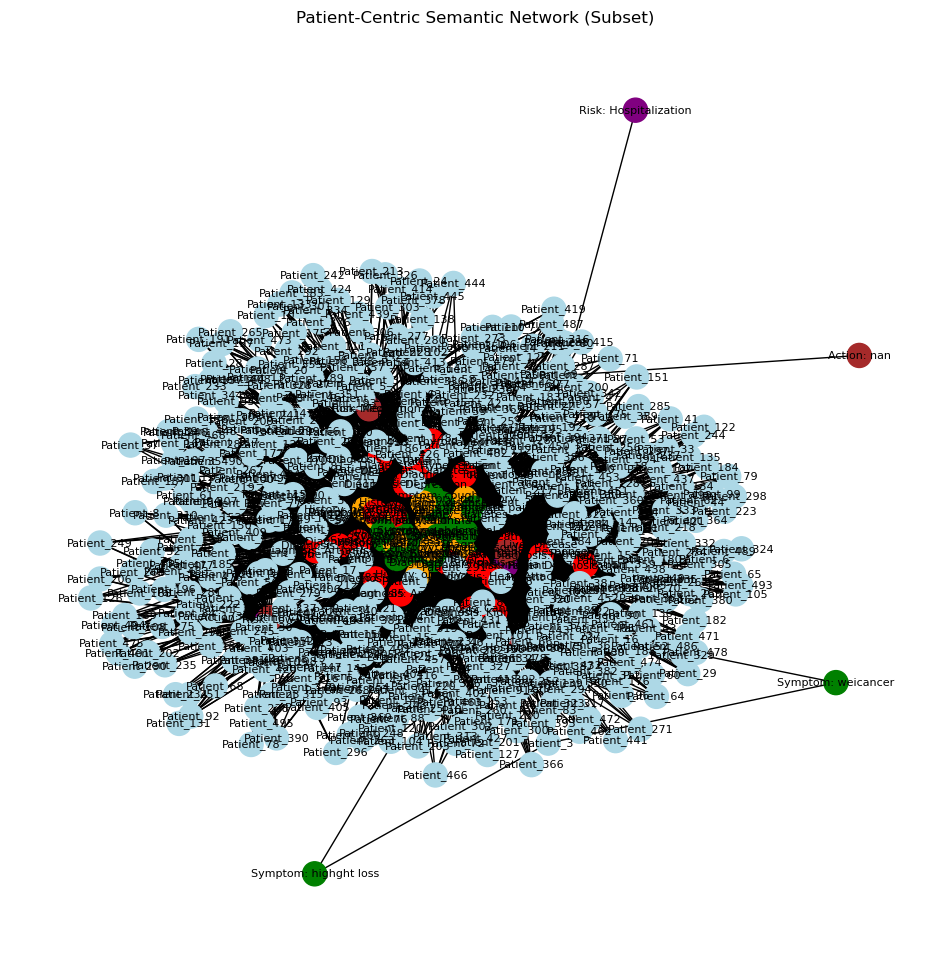

In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import re

# -------------------------------
# Step 1: Load and Clean the Data
# -------------------------------
df = pd.read_csv('patients_data.csv')

def clean_text(text):
    """Simple text cleaning: lowercase and remove non-alphanumeric characters."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s,]', '', text)  # allow commas for splitting
    return text

df['Symptoms_clean'] = df['Symptoms'].apply(clean_text)
df['Medical_History_clean'] = df['Medical_History'].apply(clean_text)

# -------------------------------
# Step 2: Build the Semantic Network
# -------------------------------
# Create an empty graph
G = nx.Graph()

# For visualization/demo, use a subset (first 500 records)
subset_df = df.head(500)

for index, row in subset_df.iterrows():
    # Create patient node (unique identifier)
    patient_node = f"Patient_{row['Patient_ID']}"
    
    # Create nodes for Diagnosis, Risk_Level, and Recommended_Action (prefix helps identify type)
    diagnosis_node = f"Diagnosis: {row['Diagnosis']}"
    risk_node = f"Risk: {row['Risk_Level']}"
    action_node = f"Action: {row['Recommended_Action']}"
    
    # Add patient node with an attribute (e.g., age)
    G.add_node(patient_node, type='patient', age=row['Age'])
    
    # Add other nodes with their types
    G.add_node(diagnosis_node, type='diagnosis')
    G.add_node(risk_node, type='risk')
    G.add_node(action_node, type='action')
    
    # Link the patient to diagnosis, risk, and recommended action
    G.add_edge(patient_node, diagnosis_node)
    G.add_edge(patient_node, risk_node)
    G.add_edge(patient_node, action_node)
    
    # Process Symptoms (assume comma-separated values)
    symptoms = row['Symptoms_clean'].split(',')
    for symptom in symptoms:
        symptom = symptom.strip()
        if symptom:
            symptom_node = f"Symptom: {symptom}"
            G.add_node(symptom_node, type='symptom')
            # Connect patient to each symptom
            G.add_edge(patient_node, symptom_node)
            # Optionally, connect symptom directly to diagnosis
            G.add_edge(symptom_node, diagnosis_node)
    
    # Process Medical History (assume comma-separated values)
    med_history = row['Medical_History_clean'].split(',')
    for condition in med_history:
        condition = condition.strip()
        if condition:
            condition_node = f"History: {condition}"
            G.add_node(condition_node, type='medical_history')
            # Connect patient to each historical condition
            G.add_edge(patient_node, condition_node)
            # Optionally, connect condition directly to diagnosis
            G.add_edge(condition_node, diagnosis_node)

# -------------------------------
# Step 3: Visualize a Subset of the Semantic Network
# -------------------------------
plt.figure(figsize=(12, 12))
# Use a spring layout for visualization
layout = nx.spring_layout(G, k=0.15, iterations=20)

# Retrieve node types to apply different colors
node_types = nx.get_node_attributes(G, 'type')

# Define a color map based on node type
color_map = []
for node in G.nodes():
    node_type = node_types.get(node, 'other')
    if node_type == 'patient':
        color_map.append('lightblue')
    elif node_type == 'diagnosis':
        color_map.append('red')
    elif node_type == 'symptom':
        color_map.append('green')
    elif node_type == 'medical_history':
        color_map.append('orange')
    elif node_type == 'risk':
        color_map.append('purple')
    elif node_type == 'action':
        color_map.append('brown')
    else:
        color_map.append('gray')

# Draw the graph; note that labels on a large graph may overlap
nx.draw_networkx(G, pos=layout, node_color=color_map, with_labels=True, font_size=8)
plt.title("Patient-Centric Semantic Network (Subset)")
plt.axis('off')
plt.show()


In [10]:
pip install torch torch-geometric

Note: you may need to restart the kernel to use updated packages.


In [11]:
!pip install torch torch-geometric

In [12]:
pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [13]:
!pip install torch torchvision torchaudio

In [14]:
!pip install torch-geometric


In [15]:
!pip install torch torchvision torchaudio
!pip install torch-geometric


In [16]:
!pip install torch torchvision torchaudio --user


In [17]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html


In [18]:
!pip install torch cluster

In [19]:
!pip install torch-cluster --user -f https://data.pyg.org/whl/torch-2.0.0+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html


In [20]:
!pip install torch torchvision torchaudio
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html


In [21]:
!pip list | grep torch

'grep' is not recognized as an internal or external command,
operable program or batch file.


In [22]:
!pip install torch-sparse

In [23]:
!pip install --no-cache-dir torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install --no-cache-dir torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install --no-cache-dir torch-cluster -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install --no-cache-dir torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install --no-cache-dir torch-geometric


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html


In [1]:
from sklearn.neighbors import NearestNeighbors

def compute_knn_edge_index(X, k):
    """
    Compute a k-nearest neighbor graph edge index from a feature tensor X.
    Returns an edge_index tensor of shape (2, num_edges).
    """
    # Convert to numpy array if X is a torch tensor
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = X

    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X_np)
    distances, indices = nbrs.kneighbors(X_np)
    # indices: shape (N, k+1); first neighbor is the point itself, so skip it.
    indices = indices[:, 1:]
    N = X_np.shape[0]
    # Build edge list: for each point, add edges to its k nearest neighbors.
    edge_index_list = []
    for i in range(N):
        for j in indices[i]:
            edge_index_list.append([i, j])
    # Convert list to numpy array and then to a torch tensor.
    edge_index = np.array(edge_index_list).T  # shape (2, num_edges)
    return torch.tensor(edge_index, dtype=torch.long)


In [2]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv  # Do not import knn_graph here
from torch_geometric.data import Data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors

# -------------------------------
# Step 1: Load and Preprocess the Data
# -------------------------------
df = pd.read_csv('patients_data.csv')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['Symptoms_clean'] = df['Symptoms'].apply(clean_text)
df['Medical_History_clean'] = df['Medical_History'].apply(clean_text)

# Use a subset for demonstration (first 1000 patients)
subset_df = df.head(1000).copy()

# -------------------------------
# Step 2: Advanced Feature Engineering (TF-IDF + SVD)
# -------------------------------
tfidf_symptoms = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
tfidf_medhist = TfidfVectorizer(max_features=500, ngram_range=(1, 2))

symptoms_tfidf = tfidf_symptoms.fit_transform(subset_df['Symptoms_clean'])
medhist_tfidf = tfidf_medhist.fit_transform(subset_df['Medical_History_clean'])

svd_symptoms = TruncatedSVD(n_components=50, random_state=42)
symptoms_reduced = svd_symptoms.fit_transform(symptoms_tfidf)

n_components_medhist = min(50, medhist_tfidf.shape[1])
svd_medhist = TruncatedSVD(n_components=n_components_medhist, random_state=42)
medhist_reduced = svd_medhist.fit_transform(medhist_tfidf)

age_feature = subset_df['Age'].values.reshape(-1, 1)
age_norm = (age_feature - age_feature.min()) / (age_feature.max() - age_feature.min())

X_features = np.hstack([age_norm, symptoms_reduced, medhist_reduced])
print("Combined feature matrix shape:", X_features.shape)

le_diag = LabelEncoder()
subset_df['Diagnosis_encoded'] = le_diag.fit_transform(subset_df['Diagnosis'])
y = subset_df['Diagnosis_encoded'].values
num_classes = len(le_diag.classes_)
print("Number of Diagnosis classes:", num_classes)

# -------------------------------
# Step 3: Build a Patient Graph using KNN (Fallback Implementation)
# -------------------------------
def compute_knn_edge_index(X, k):
    """
    Compute a k-nearest neighbor graph edge index from a feature tensor X.
    Returns an edge_index tensor of shape (2, num_edges).
    """
    # Convert to numpy array if X is a torch tensor
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = X

    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X_np)
    distances, indices = nbrs.kneighbors(X_np)
    # indices: shape (N, k+1); skip the first column (the point itself)
    indices = indices[:, 1:]
    N = X_np.shape[0]
    edge_index_list = []
    for i in range(N):
        for j in indices[i]:
            edge_index_list.append([i, j])
    edge_index = np.array(edge_index_list).T  # shape (2, num_edges)
    return torch.tensor(edge_index, dtype=torch.long)

X_tensor = torch.tensor(X_features, dtype=torch.float)
edge_index = compute_knn_edge_index(X_tensor, k=10)
print("Edge index shape:", edge_index.shape)

data = Data(x=X_tensor, edge_index=edge_index, y=torch.tensor(y, dtype=torch.long))
print("Graph data prepared with", data.num_nodes, "nodes.")

# -------------------------------
# Step 4: Define a GCN Model (Hybrid: Graph + NLP Features)
# -------------------------------
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, num_classes)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return F.log_softmax(x, dim=1)

num_node_features = X_tensor.shape[1]
hidden_channels = 64
model = GCN(num_node_features, hidden_channels, num_classes)
print(model)

# -------------------------------
# Step 5: Train the Hybrid Model
# -------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.NLLLoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    with torch.no_grad():
        out = model(data)
        _, pred = out.max(dim=1)
        correct = pred.eq(data.y).sum().item()
        acc = correct / data.num_nodes
    return acc

for epoch in range(1, 101):
    loss = train()
    acc = test()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

print("Training complete.")

c:\ProgramData\anaconda3\Lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\ProgramData\anaconda3\Lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\ProgramData\anaconda3\Lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its u

Combined feature matrix shape: (1000, 70)
Number of Diagnosis classes: 21
Edge index shape: torch.Size([2, 10000])
Graph data prepared with 1000 nodes.
GCN(
  (conv1): GCNConv(70, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=21, bias=True)
)
Epoch 010, Loss: 2.9010, Accuracy: 0.1110
Epoch 020, Loss: 2.7674, Accuracy: 0.1640
Epoch 030, Loss: 2.6059, Accuracy: 0.2160
Epoch 040, Loss: 2.4198, Accuracy: 0.2670
Epoch 050, Loss: 2.2408, Accuracy: 0.2990
Epoch 060, Loss: 2.0697, Accuracy: 0.3330
Epoch 070, Loss: 1.9228, Accuracy: 0.3650
Epoch 080, Loss: 1.7875, Accuracy: 0.4020
Epoch 090, Loss: 1.6599, Accuracy: 0.4420
Epoch 100, Loss: 1.5467, Accuracy: 0.4700
Training complete.


In [ ]:
# Rule-Based Recommendation System for Next Best Action

def recommend_next_action(risk_level, diagnosis):
    """
    Recommend the next best action based on predicted risk level and diagnosis.
    
    Parameters:
        risk_level (str): The predicted risk level (e.g., "High", "Medium", "Low").
        diagnosis (str): The predicted or actual diagnosis.
        
    Returns:
        str: Recommended action.
    """
    # Define a dictionary of rules
    rules = {
        "High": {
            # If high risk, check for specific critical diagnoses.
            "Heart Attack": "Immediate ICU Admission",
            "Stroke": "Immediate ICU Admission",
            "default": "Emergency Response"
        },
        "Medium": {
            # For medium risk, hospitalization is typical.
            "Diabetes": "Hospitalization with Endocrinology Consult",
            "Hypertension": "Hospitalization with Cardiology Consult",
            "default": "Hospitalization"
        },
        "Low": {
            # For low risk, a less aggressive approach may suffice.
            "default": "Outpatient Follow-Up and Medication"
        }
    }
    
    # Use the rules: if risk level is known, check for diagnosis-specific rule
    if risk_level in rules:
        # Check if there is a special rule for the given diagnosis
        if diagnosis in rules[risk_level]:
            return rules[risk_level][diagnosis]
        else:
            # Use the default recommendation for that risk level
            return rules[risk_level]["default"]
    else:
        # If risk level is unknown, recommend further evaluation
        return "Further Evaluation Required"

# --- Example Usage ---
# Assume these predictions come from your model or other clinical data
predicted_risk_level = "Low"       # Example: "High", "Medium", or "Low"
predicted_diagnosis  = "COVID-19"  # Example diagnosis

# Get the recommended action based on the rules
recommended_action = recommend_next_action(predicted_risk_level, predicted_diagnosis)
print("Recommended Action:", recommended_action)

Recommended Action: Outpatient Follow-Up and Medication


In [27]:
def recommend_next_action(risk_level, diagnosis):
    """
    Recommend the next best action based on predicted risk level and diagnosis.
    
    Parameters:
        risk_level (str): The predicted risk level (e.g., "High", "Medium", "Low").
        diagnosis (str): The predicted or actual diagnosis.
        
    Returns:
        str: Recommended action.
    """
    # Updated rules to match dataset recommendations
    rules = {
        "High": {
            # For a high risk patient, if the diagnosis is "Heart Attack", the rule now returns "Emergency Response"
            "Heart Attack": "Emergency Response",
            "Stroke": "Emergency Response",
            "default": "Emergency Response"
        },
        "Medium": {
            "Diabetes": "Hospitalization with Endocrinology Consult",
            "Hypertension": "Hospitalization with Cardiology Consult",
            "default": "Hospitalization"
        },
        "Low": {
            "default": "Outpatient Follow-Up and Medication"
        }
    }
    
    # Look up the risk level, then check for a specific diagnosis
    if risk_level in rules:
        return rules[risk_level].get(diagnosis, rules[risk_level]["default"])
    else:
        return "Further Evaluation Required"

# --- Example Usage ---
predicted_risk_level = "High"       
predicted_diagnosis  = "Heart Attack"  # As per your model's prediction or dataset

recommended_action = recommend_next_action(predicted_risk_level, predicted_diagnosis)
print("Recommended Action:", recommended_action)


Recommended Action: Emergency Response


In [28]:
# Assume the following variables are defined from your previous steps:
# - X_tensor: a torch tensor of shape (1000, 70) with patient features.
# - data: a PyTorch Geometric Data object.
# - model: your trained GCN model.
# - le_diag: the LabelEncoder that maps diagnosis names to indices and vice versa.

# For demonstration, we will predict the diagnosis for the first patient sample.
model.eval()
with torch.no_grad():
    # Predict for all nodes; here we extract the prediction for the first patient.
    out = model(data)  
    pred = out.argmax(dim=1)  # shape (num_nodes,)
    
predicted_index = pred[0].item()
predicted_diagnosis = le_diag.inverse_transform([predicted_index])[0]
print("Predicted Diagnosis:", predicted_diagnosis)

# Define a simple heuristic to determine risk level based on diagnosis.
# For example, if the diagnosis is in a list of critical conditions, assign "High" risk.
critical_conditions = ["Heart Attack", "Stroke", "Cancer", "Liver Disease", "COVID-19"]  # Example list
if predicted_diagnosis in critical_conditions:
    predicted_risk_level = "High"
else:
    # Here you can add more logic; for simplicity, we use "Medium" risk for others.
    predicted_risk_level = "Medium"

print("Predicted Risk Level:", predicted_risk_level)

# Define the rule-based recommendation function.
def recommend_next_action(risk_level, diagnosis):
    """
    Recommend the next best action based on risk level and diagnosis.
    You can adjust these rules as needed to match your dataset.
    """
    rules = {
        "High": {
            "default": "Emergency Response",  # For any high-risk condition.
            # If needed, you can specify diagnosis-specific rules:
            # "Heart Attack": "Emergency Response",
        },
        "Medium": {
            "default": "Hospitalization",
        },
        "Low": {
            "default": "Outpatient Follow-Up and Medication"
        }
    }
    # Return the diagnosis-specific recommendation if available; otherwise, the default.
    return rules.get(risk_level, {}).get(diagnosis, rules.get(risk_level, {}).get("default", "Further Evaluation Required"))

# Get the recommended action using the rule-based function.
recommended_action = recommend_next_action(predicted_risk_level, predicted_diagnosis)
print("Recommended Action:", recommended_action)


Predicted Diagnosis: Liver Disease
Predicted Risk Level: High
Recommended Action: Emergency Response


In [29]:
# Check that the model is defined
try:
    model.eval()
except NameError:
    raise NameError("The variable 'model' is not defined. Please run the model training cell before executing this code.")

import torch

# --- Prediction for a Patient and Generating a Recommendation ---

# For demonstration, we predict the diagnosis for the first patient in the graph.
with torch.no_grad():
    outputs = model(data)           # Forward pass
    predictions = outputs.argmax(dim=1)  # Get the predicted class for each node

# Select a patient (e.g., the first patient)
patient_index = 1
predicted_index = predictions[patient_index].item()

# Map the predicted index back to a diagnosis label using your label encoder.
predicted_diagnosis = le_diag.inverse_transform([predicted_index])[0]
print("Predicted Diagnosis for patient {}: {}".format(patient_index, predicted_diagnosis))

# --- Assign a Risk Level ---
# For example, you can define a list of critical conditions.
critical_conditions = ["Heart Attack", "Stroke", "Cancer", "Liver Disease", "COVID-19"]
if predicted_diagnosis in critical_conditions:
    risk_level = "High"
else:
    risk_level = "Medium"  # You can extend this logic for a "Low" category if needed.

print("Predicted Risk Level:", risk_level)

# --- Rule-Based Recommendation ---
def recommend_next_action(risk_level, diagnosis):
    """
    Recommend the next best action based on risk level and diagnosis.
    Adjust the rules as necessary to align with your clinical guidelines.
    """
    rules = {
        "High": {
            "default": "Emergency Response"
        },
        "Medium": {
            "default": "Hospitalization"
        },
        "Low": {
            "default": "Outpatient Follow-Up and Medication"
        }
    }
    # Return diagnosis-specific recommendation if available; otherwise, default.
    return rules.get(risk_level, {}).get(diagnosis, rules.get(risk_level, {}).get("default", "Further Evaluation Required"))

recommended_action = recommend_next_action(risk_level, predicted_diagnosis)
print("Recommended Action:", recommended_action)


Predicted Diagnosis for patient 1: nan
Predicted Risk Level: Medium
Recommended Action: Hospitalization


In [ ]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import re
import joblib
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# -------------------------------
# Step 1: Load Data
# -------------------------------
df = pd.read_csv("patients_data.csv")
print(f"Original dataset shape: {df.shape}")

# -------------------------------
# Step 2: Clean Text Columns
# -------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['Symptoms_clean'] = df['Symptoms'].apply(clean_text)
df['Medical_History_clean'] = df['Medical_History'].apply(clean_text)

# -------------------------------
# Step 3: Drop Rare Classes
# -------------------------------
df = df.groupby("Diagnosis").filter(lambda x: len(x) > 1)
print(f"After dropping rare classes: {df.shape}")

# Encode target
le_diag = LabelEncoder()
df['Diagnosis_encoded'] = le_diag.fit_transform(df['Diagnosis'])
y = df['Diagnosis_encoded'].values
joblib.dump(le_diag, "label_encoder.pkl")

# -------------------------------
# Step 4: TF-IDF + SVD for Symptoms
# -------------------------------
tfidf_symptoms = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
symptoms_tfidf = tfidf_symptoms.fit_transform(df['Symptoms_clean'])
svd_symptoms = TruncatedSVD(
    n_components=min(50, symptoms_tfidf.shape[1]), random_state=42
)
symptoms_svd = svd_symptoms.fit_transform(symptoms_tfidf)

joblib.dump(tfidf_symptoms, "tfidf_symptoms.pkl")
joblib.dump(svd_symptoms, "svd_symptoms.pkl")

# -------------------------------
# Step 5: TF-IDF + SVD for Medical History
# -------------------------------
tfidf_medhist = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
medhist_tfidf = tfidf_medhist.fit_transform(df['Medical_History_clean'])
svd_medhist = TruncatedSVD(
    n_components=min(50, medhist_tfidf.shape[1]), random_state=42
)
medhist_svd = svd_medhist.fit_transform(medhist_tfidf)

joblib.dump(tfidf_medhist, "tfidf_medhist.pkl")
joblib.dump(svd_medhist, "svd_medhist.pkl")

# -------------------------------
# Step 6: Scale Age
# -------------------------------
age_values = df['Age'].values.reshape(-1, 1)
age_scaler = MinMaxScaler().fit(age_values)
age_norm = age_scaler.transform(age_values)
joblib.dump(age_scaler, "age_scaler.pkl")

# -------------------------------
# Step 7: Combine Features
# -------------------------------
X_features = np.hstack([age_norm, symptoms_svd, medhist_svd])

feature_meta = {
    "order": ["age_norm", "symptoms_svd", "medhist_svd"],
    "symptoms_svd_dim": svd_symptoms.n_components,
    "medhist_svd_dim": svd_medhist.n_components,
}
joblib.dump(feature_meta, "feature_meta.pkl")

# -------------------------------
# Step 8: Train Fast Model for Streamlit
# -------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

fast_model = LogisticRegression(max_iter=500, n_jobs=-1)
fast_model.fit(X_train, y_train)
joblib.dump(fast_model, "fast_inference_model.pkl")

print("✅ All artifacts saved successfully!")
print("Saved files:")
print(" - age_scaler.pkl")
print(" - tfidf_symptoms.pkl, svd_symptoms.pkl")
print(" - tfidf_medhist.pkl, svd_medhist.pkl")
print(" - label_encoder.pkl, feature_meta.pkl")
print(" - fast_inference_model.pkl")


Original dataset shape: (300000, 7)
After dropping rare classes: (299999, 9)
✅ All artifacts saved successfully!
Saved files:
 - age_scaler.pkl
 - tfidf_symptoms.pkl, svd_symptoms.pkl
 - tfidf_medhist.pkl, svd_medhist.pkl
 - label_encoder.pkl, feature_meta.pkl
 - fast_inference_model.pkl


In [3]:
import pandas as pd

df = pd.read_csv("patients_data.csv")
print("Columns in dataset:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())


Columns in dataset: ['Patient_ID', 'Age', 'Symptoms', 'Medical_History', 'Diagnosis', 'Risk_Level', 'Recommended_Action']

First 5 rows:
   Patient_ID  Age                                       Symptoms  \
0           1   66        Fatigue, Dizziness, Cough, Palpitations   
1           2   45                   Fatigue, Skin Rash, Headache   
2           3   27  WeiCancer,Highght Loss, Skin Rash, Joint Pain   
3           4   77                                       Headache   
4           5   26         Fever, Vomiting, Sore Throat, Headache   

  Medical_History      Diagnosis       Risk_Level  Recommended_Action  
0      Depression  Liver Disease             High  Emergency Response  
1   Heart Disease            NaN  Hospitalization                 NaN  
2   Liver Disease         Cancer             High     Hospitalization  
3      Depression  Liver Disease             High  Emergency Response  
4        Diabetes       Diabetes           Medium          Medication  


In [4]:
import pandas as pd

df = pd.read_csv("patients_data.csv")
print(df.columns.tolist())


['Patient_ID', 'Age', 'Symptoms', 'Medical_History', 'Diagnosis', 'Risk_Level', 'Recommended_Action']
